# VeriGym - Comparing exploration policies

## Imports

In [1]:
import stormpy
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import logging

import verigym
from verigym.abstraction.gym_utils.transform_observation import ReplaceInfObservation
from verigym.abstraction.abstractionmapper import linspace_mapper
from verigym.frameworks.stormpy.stormpy_utils import build_stormpy_mdp
from verigym.frameworks.stormpy.stormpypolicy import StormpyPolicy
from verigym.policy.randomized import RandomizedPolicy
from verigym.policy.qvalue import (
    QValuePolicy,
    ActiveLearningPolicy,
    EntropyLearningPolicy,
)

logging.getLogger().setLevel(logging.ERROR)


def get_average_episode_length(trajectories):
    return np.mean([len(traj) for traj in trajectories])


def get_mean_reward_from_trajectories(trajectories):
    rewards = []
    for trajectory in trajectories:
        trajectory_rewards = list(map(lambda tup: tup[2], trajectory))
        rewards.append(np.sum(trajectory_rewards))
    return float(np.mean(rewards))


def get_explored_state_action_pairs(abstracted_model):
    """Returns the number of explored states and explored state-action pairs of an abstraction."""
    T_dict = abstracted_model.transition_function.T_dict
    explored_states = set()
    explored_state_action_pairs = 0
    for s in T_dict:
        for a in T_dict[s]:
            if len(T_dict[s][a]) > 0:
                explored_states.add(s)
                explored_state_action_pairs += 1
    return len(explored_states), explored_state_action_pairs

## 1. Environment

We use the  OpenAI gymnasium Cart Pole environment for this demo:

In [2]:
# 1. Load cart pole in gym
gym_env = gym.make("MountainCar-v0")
print("Environment type: ", type(gym_env))

# 2. For discretization, replace (-inf, inf) observation bounds
gym_env = ReplaceInfObservation(gym_env, neg_inf=-5, pos_inf=5)
print("Observation space shape: ", gym_env.observation_space.shape)
print("Observation upper bounds: ", gym_env.observation_space.high)
print("Observation lower bounds: ", gym_env.observation_space.low)
print("Type of observation space: ", type(gym_env.observation_space))

Environment type:  <class 'gymnasium.wrappers.common.TimeLimit'>
Observation space shape:  (2,)
Observation upper bounds:  [0.6  0.07]
Observation lower bounds:  [-1.2  -0.07]
Type of observation space:  <class 'gymnasium.spaces.box.Box'>


Now, we load the `gym_env` into our framework, turning it into a (`gym`-like) `VeriGymEnv`:

In [3]:
# Create a VeriGymEnv from gym env
generative_model = verigym.GenerativeEnv.from_gymnasium(gym_env)

print("Environment type: ", type(generative_model))
print("Observation space shape: ", generative_model.observation_space.shape)
print("Type of observation space: ", type(generative_model.observation_space))

Environment type:  <class 'verigym.environments.generativeenv.GenerativeEnv_from_gym'>
Observation space shape:  (2,)
Type of observation space:  <class 'gymnasium.spaces.box.Box'>


## 2. Abstraction mapper

All exploration policies are compared on the same discretization of the state and action space.
Note that the Q-value based exploration policies operate *on the abstract space*, hence they require the `abstraction_mapper` as well.

In [4]:
abstraction_mapper = linspace_mapper(
    env=generative_model,
    n_bins_states=20,
    n_bins_actions=3,
)

print(f"The abstract observation space has {abstraction_mapper.abstract_n_states} states!")
print(f"The abstract action space has {abstraction_mapper.abstract_n_actions} actions!")

The abstract observation space has 400 states!
The abstract action space has 3 actions!


## 3. Exploration policies

The exploration policy determines which interactions with the original environment are used to learn the abstraction. We compare:

1. `RandomizedPolicy`: Uniformly samples actions from the original action space (baseline).
2. `QValuePolicy`: Epsilon-greedy (softmax) w.r.t. Q-values computed on the abstraction learned *so far*, using the environment's reward.
3. `ActiveLearningPolicy`: Q-values w.r.t. an exploration reward $1 / N(s, a)$ on the state-action counts, following Araya-López et al. (2012). Unvisited state-action pairs receive the maximal reward.
4. `EntropyLearningPolicy`: Iteratively computes a maximum-entropy policy over the state distribution, following Hazan et al. (2019).

The Q-value based policies are *interleaving*: `create_abstraction` runs for `n_iterations` iterations, and before each iteration it calls `exploration_policy.update_for_abstraction_refinement(...)` with the data gathered so far. For `RandomizedPolicy`, this call does nothing.

Every policy gets the same total budget of `n_iterations * num_steps` environment steps.

In [ ]:
n_iterations = 100
num_steps = int(5e3)  # steps per iteration
epsilon = 0.1 # exploration threshold for the epsilon-greedy policies

# Constructors, such that every abstraction starts from a fresh policy
exploration_policies = {
    "Randomized": lambda: RandomizedPolicy(generative_model),
    "QValue": lambda: QValuePolicy(
        generative_model, abstraction_mapper, epsilon=epsilon
    ),
    "ActiveLearning": lambda: ActiveLearningPolicy(
        generative_model, abstraction_mapper, epsilon=epsilon
    ),
    "EntropyLearning": lambda: EntropyLearningPolicy(
        generative_model, abstraction_mapper
    ),
}

## 4. Abstraction

For each exploration policy, we learn the transition and reward functions of the abstraction.

In [6]:
# TODO: record timings, change random to 1 iteration

abstracted_models = {}
for name, make_policy in exploration_policies.items():
    print(f"--- {name} ---")
    abstracted_models[name] = verigym.create_abstraction(
        original_env=generative_model,
        abstraction_mapper=abstraction_mapper,
        exploration_policy=make_policy(),
        num_steps=num_steps,
        n_iterations=n_iterations,
        multithreading=False,
    )

--- Randomized ---
Simulation time: 0.0653s
Trajectories in dataset: 25
Learning Abstraction: 0.0639s
Simulation time: 0.0649s
Trajectories in dataset: 25
Learning Abstraction: 0.0613s
Simulation time: 0.0733s
Trajectories in dataset: 25
Learning Abstraction: 0.0591s
Simulation time: 0.0630s
Trajectories in dataset: 25
Learning Abstraction: 0.0623s
Simulation time: 0.0733s
Trajectories in dataset: 25
Learning Abstraction: 0.0780s
Simulation time: 0.0910s
Trajectories in dataset: 25
Learning Abstraction: 0.0993s
Simulation time: 0.1099s
Trajectories in dataset: 25
Learning Abstraction: 0.1256s
Simulation time: 0.1268s
Trajectories in dataset: 25
Learning Abstraction: 0.1409s
Simulation time: 0.1452s
Trajectories in dataset: 25
Learning Abstraction: 0.1529s
Simulation time: 0.1613s
Trajectories in dataset: 25
Learning Abstraction: 0.1974s
Simulation time: 0.2332s
Trajectories in dataset: 25
Learning Abstraction: 0.1838s
Simulation time: 0.2165s
Trajectories in dataset: 25
Learning Abstra

/home/merlijn/GitRepos/VeriGym/src/verigym/abstraction/learn_abstraction.py:384: RuntimeWarning: invalid value encountered in divide
  state_distr /= state_distr.sum()


Simulation time: 0.6008s
Trajectories in dataset: 25
Learning Abstraction: 0.1347s
Simulation time: 0.4512s
Trajectories in dataset: 25
Learning Abstraction: 0.1320s
Simulation time: 0.4325s
Trajectories in dataset: 25
Learning Abstraction: 0.1224s
Simulation time: 0.4429s
Trajectories in dataset: 25
Learning Abstraction: 0.1201s
Simulation time: 0.4409s
Trajectories in dataset: 25
Learning Abstraction: 0.1172s
Simulation time: 0.5354s
Trajectories in dataset: 25
Learning Abstraction: 0.1343s
Simulation time: 0.4855s
Trajectories in dataset: 25
Learning Abstraction: 0.1225s
Simulation time: 0.4498s
Trajectories in dataset: 25
Learning Abstraction: 0.1175s
Simulation time: 0.4479s
Trajectories in dataset: 25
Learning Abstraction: 0.1428s
Simulation time: 0.4577s
Trajectories in dataset: 25
Learning Abstraction: 0.1227s
Simulation time: 0.4571s
Trajectories in dataset: 25
Learning Abstraction: 0.1214s
Simulation time: 0.4460s
Trajectories in dataset: 25
Learning Abstraction: 0.1210s
Simu

/home/merlijn/GitRepos/VeriGym/src/verigym/abstraction/learn_abstraction.py:384: RuntimeWarning: invalid value encountered in divide
  state_distr /= state_distr.sum()


Simulation time: 0.5802s
Trajectories in dataset: 25
Learning Abstraction: 0.1488s
Simulation time: 0.5756s
Trajectories in dataset: 25
Learning Abstraction: 0.1448s
Simulation time: 0.5341s
Trajectories in dataset: 25
Learning Abstraction: 0.1537s
Simulation time: 0.5942s
Trajectories in dataset: 25
Learning Abstraction: 0.1552s
Simulation time: 0.5592s
Trajectories in dataset: 25
Learning Abstraction: 0.1441s
Simulation time: 0.5545s
Trajectories in dataset: 25
Learning Abstraction: 0.1531s
Simulation time: 0.5429s
Trajectories in dataset: 25
Learning Abstraction: 0.1554s
Simulation time: 0.5444s
Trajectories in dataset: 25
Learning Abstraction: 0.1518s
Simulation time: 0.5402s
Trajectories in dataset: 25
Learning Abstraction: 0.1447s
Simulation time: 0.5298s
Trajectories in dataset: 25
Learning Abstraction: 0.1387s
Simulation time: 0.4997s
Trajectories in dataset: 25
Learning Abstraction: 0.1287s
Simulation time: 0.4877s
Trajectories in dataset: 25
Learning Abstraction: 0.1363s
Simu

/home/merlijn/GitRepos/VeriGym/src/verigym/policy/qvalue.py:226: RuntimeWarning: divide by zero encountered in log
  R_learning[sidx][aidx] = min(Rmax, -(np.log(d_pi[sidx]) + 1))


Simulation time: 0.5416s
Trajectories in dataset: 25
Learning Abstraction: 0.1446s
Simulation time: 0.4352s
Trajectories in dataset: 25
Learning Abstraction: 0.1356s
Simulation time: 0.4317s
Trajectories in dataset: 25
Learning Abstraction: 0.1356s
Simulation time: 0.4700s
Trajectories in dataset: 25
Learning Abstraction: 0.1445s
Simulation time: 0.4638s
Trajectories in dataset: 25
Learning Abstraction: 0.1413s
Simulation time: 0.4407s
Trajectories in dataset: 25
Learning Abstraction: 0.1516s
Simulation time: 0.4667s
Trajectories in dataset: 25
Learning Abstraction: 0.1434s
Simulation time: 0.4593s
Trajectories in dataset: 25
Learning Abstraction: 0.1574s
Simulation time: 0.4627s
Trajectories in dataset: 25
Learning Abstraction: 0.1598s
Simulation time: 0.4276s
Trajectories in dataset: 27
Learning Abstraction: 0.1418s
Simulation time: 0.4415s
Trajectories in dataset: 27
Learning Abstraction: 0.1443s
Simulation time: 0.4702s
Trajectories in dataset: 28
Learning Abstraction: 0.1517s
Simu

### Coverage of the abstraction

A first measure for the quality of an exploration policy is how much of the abstract state-action space it covers.

In [7]:
coverage = {
    name: get_explored_state_action_pairs(model)
    for name, model in abstracted_models.items()
}

n_state_action_pairs = abstraction_mapper.abstract_n_states * abstraction_mapper.abstract_n_actions
print(f"{'Policy':<16} {'States':>8} {'State-action pairs':>20}")
for name, (n_states, n_pairs) in coverage.items():
    print(f"{name:<16} {n_states:>8} {n_pairs:>20}")
print(f"{'Total':<16} {abstraction_mapper.abstract_n_states:>8} {n_state_action_pairs:>20}")

Policy             States   State-action pairs
Randomized             78                  212
QValue                145                  402
ActiveLearning        125                  364
EntropyLearning       296                  882
Total                 400                 1200


## 5. Model checking

We model check each abstraction in `stormpy` w.r.t. maximal cumulative discounted reward.

Therefore, we
1. Export the model to a `stormpy.storage.SparseMdp`
2. Model check the MDP in `stormpy` and receive a scheduler (policy)

In [8]:
gamma = 0.95  # discount factor
prop = stormpy.parse_properties(f"Rmax=?[Cdiscount={gamma}]")[
    0
]  # checking for cumulative discounted reward

stormpy_mdps = {}
schedulers = {}
for name, abstracted_model in abstracted_models.items():
    stormpy_mdps[name] = build_stormpy_mdp(abstracted_model)
    result = stormpy.check_model_sparse(
        stormpy_mdps[name], prop, extract_scheduler=True
    )
    schedulers[name] = result.scheduler

## 6. Policy evaluation

Finally, we evaluate the model checked policies on the original and the abstract models.

1. We convert the `stormpy` policy to a `verigym.StormpyPolicy`
2. We apply it to both the original and the abstract model.

In [9]:
n_simulation_steps = int(1e4)

mean_rewards_original = {}
mean_rewards_abstracted = {}
for name, abstracted_model in abstracted_models.items():
    # policy mapped to the original model
    verigym_policy = StormpyPolicy(
        schedulers[name], abstracted_model.abstraction_map, stormpy_mdps[name]
    )
    # policy on the abstract model
    identity_mapper = verigym.AbstractionMapper.initialize_identity_mapper(
        abstracted_model.observation_space, abstracted_model.action_space
    )
    verigym_policy_on_abstracted = StormpyPolicy(
        schedulers[name], identity_mapper, stormpy_mdps[name]
    )

    # simulation in the original (continuous) model
    trajectories_original = generative_model.simulate(
        policy=verigym_policy,
        n_steps=n_simulation_steps,
    )
    mean_rewards_original[name] = get_mean_reward_from_trajectories(
        trajectories_original
    )

    # simulation in the abstracted model
    trajectories_abstracted = abstracted_model.simulate(
        policy=verigym_policy_on_abstracted,
        n_steps=n_simulation_steps,
    )
    mean_rewards_abstracted[name] = get_mean_reward_from_trajectories(
        trajectories_abstracted
    )

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulating:   0%|          | 0/10000 [00:00<?, ?it/s]

In [10]:
print("Comparing the mean cumulative reward of the abstract policies:")
print(f"{'Policy':<16} {'Original':>12} {'Abstract':>12}")
for name in abstracted_models:
    print(
        f"{name:<16} {mean_rewards_original[name]:>12.2f} {mean_rewards_abstracted[name]:>12.2f}"
    )

Comparing the mean cumulative reward of the abstract policies:
Policy               Original     Abstract
Randomized            -200.00    -10000.00
QValue                -200.00    -10000.00
ActiveLearning        -200.00      -238.10
EntropyLearning       -135.14      -149.25


# Visualize the comparison

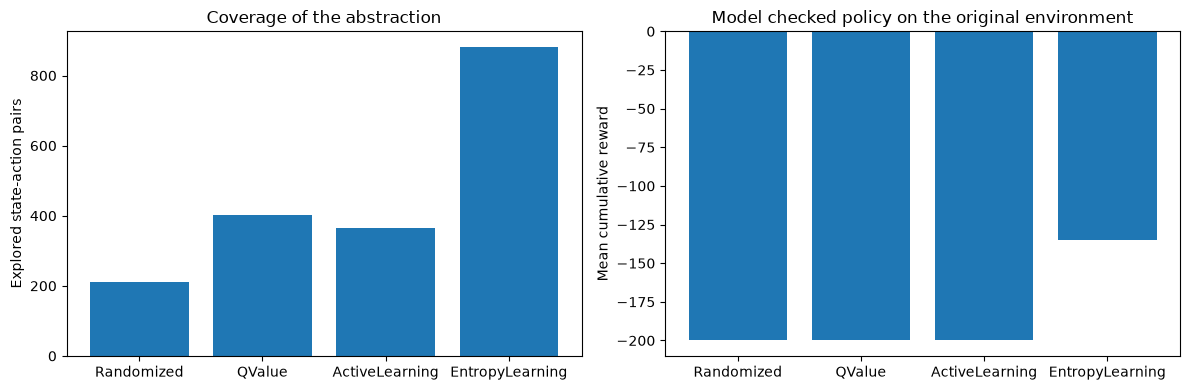

In [11]:
names = list(abstracted_models)
x = np.arange(len(names))

fig, (ax_coverage, ax_reward) = plt.subplots(1, 2, figsize=(12, 4))

ax_coverage.bar(x, [coverage[name][1] for name in names])
ax_coverage.set_xticks(x, names)
ax_coverage.set_ylabel("Explored state-action pairs")
ax_coverage.set_title("Coverage of the abstraction")

ax_reward.bar(x, [mean_rewards_original[name] for name in names])
ax_reward.set_xticks(x, names)
ax_reward.set_ylabel("Mean cumulative reward")
ax_reward.set_title("Model checked policy on the original environment")

fig.tight_layout()
plt.show()